# Ice-core data preprocessing

Single-direction, reproducible pipeline: raw files → missing-value normalization → site mapping → temporal alignment → quality control → short-gap interpolation → coordinate tables and audit reports.

Inputs are read only from `dataset/icecore/data_ori`. Raw files are never overwritten.

In [2]:
from pathlib import Path
import re
import numpy as np
import pandas as pd

PROJECT_ROOT = Path.cwd().resolve().parent if Path.cwd().name == 'vis' else Path.cwd().resolve()
DATA_ROOT = PROJECT_ROOT / 'dataset/icecore'
RAW_ROOT = DATA_ROOT / 'data_ori'
CHEM_RAW = RAW_ROOT / 'CLIVASH2k Antarctic ice core chemistry database(2000年).csv'
ACCUM_RAW = RAW_ROOT / 'Regional Antarctic snow accumulation over the past 1000 years.xlsx'
META_RAW = RAW_ROOT / 'metadata_annual.csv'

YEAR_START, YEAR_END = 1897, 1996
MAX_MISSING_RATE = 0.20
MAX_INTERNAL_GAP = 5
MAX_EDGE_GAP = 5

for folder in [DATA_ROOT/'chem', DATA_ROOT/'accum', DATA_ROOT/'qc']:
    folder.mkdir(parents=True, exist_ok=True)

print('Project:', PROJECT_ROOT)
print(f'Window: {YEAR_START}–{YEAR_END}')

Project: /Users/liulei/Desktop/SEMPO_copy0707
Window: 1897–1996


In [3]:
# 1. Read raw Na-flux data and normalize only documented missing sentinels.
chem_raw = pd.read_csv(CHEM_RAW, comment='#')
chem_raw = chem_raw.replace(-999.99, np.nan).rename(columns={'Year CE': 'year'})
chem_raw['year'] = pd.to_numeric(chem_raw['year'], errors='raise').astype(int)
for col in chem_raw.columns[1:]:
    chem_raw[col] = pd.to_numeric(chem_raw[col], errors='coerce')

# Keep this source-shaped file: no mapping, aggregation, truncation, or interpolation.
chem_raw.rename(columns={'year': 'Year CE'}).to_csv(DATA_ROOT/'chem/merged_chem.csv', index=False)
print('Na flux raw table:', chem_raw.shape)

Na flux raw table: (2020, 118)


In [4]:
# 2. Read the site-level accumulation measurements at full workbook precision.
accum_sheet = pd.read_excel(ACCUM_RAW, sheet_name='Original data', header=None)
accum_raw = accum_sheet.iloc[7:].copy()
accum_raw.columns = accum_sheet.iloc[6].tolist()
accum_raw = accum_raw.rename(columns={accum_raw.columns[0]: 'year'}).reset_index(drop=True)
accum_raw.columns = [str(c).strip() for c in accum_raw.columns]
accum_raw['year'] = pd.to_numeric(accum_raw['year'], errors='raise').astype(int)
for col in accum_raw.columns[1:]:
    accum_raw[col] = pd.to_numeric(accum_raw[col], errors='coerce')
accum_raw.to_csv(DATA_ROOT/'accum/merged_accumulation.csv', index=False)
print('Accumulation raw table:', accum_raw.shape)

Accumulation raw table: (2062, 80)


In [5]:
# 3. Map chemistry names to accumulation names before temporal filtering.
DIRECT_MAP = {
 '105km':'105 km', 'Bruce Plateau':'Bruce Plateau', 'Ferrigno':'Ferrigno', 'Gomez':'Gomez',
 'ITASE-00-1':'ITASE-00-1', 'ITASE-00-3':'ITASE-00-3', 'ITASE-00-4':'ITASE-00-4', 'ITASE-00-5':'ITASE-00-5',
 'ITASE-01-1':'ITASE-01-1', 'ITASE-01-2':'ITASE-01-2', 'ITASE-01-3':'ITASE-01-3', 'ITASE-01-4':'ITASE-01-4',
 'ITASE-01-5':'ITASE-01-5', 'ITASE-02-4':'ITASE-02-4', 'ITASE-02-7':'ITASE-02-7',
 'ITASE-99-1':'ITASE-99-1', 'PIG2010':'PIG2010', 'THW2010':'THW2010', 'DIV2010':'DIV2010'}
APPROX_MAP = {
 'DML17C98_33(B33)':'B33 6.4983E', 'CWA_a_2013':'CWA-A', 'CWA_d_2013':'CWA-D',
 'DML05':'FB97DML05', 'B40':'FB9807', 'EDML':'FB9807', 'ISO-ICE_spa':'FB9807',
 'ISO-ICE_spb':'FB9807', 'DML03C98_09(FB9809)':'FB9809',
 'DML15C98_14(FB9814)':'FB9814', 'FIS_S100':'Fimbulisen s100',
 'DSS0506':'Law Dome (2015)',
 'LawDome_DSS':'Law Dome (2015)', 'RIDS95A_2013':'RIDS-A',
 'RIDS95B_2013':'RIDS-B', 'RIDS95C_2013':'RIDS-C', 'SDM1994_2013':'SDM-94',
 'SPICE':'SPOLE 0EW', 'SouthPole1995_2013':'SPOLE 0EW',
 'TD05':'Talos Dome 159.07575E', 'UpC_2013':'UP-C', 'WDC06A':'WD05A 112.125W',
 'BH-1':'vrs-13 (vostok stack)', 'BH-2':'vrs-13 (vostok stack)',
 'Vostok5G_ic':'vrs-13 (vostok stack)',
 'Vostok5G_icp-ms_hplc':'vrs-13 (vostok stack)'}
SITE_MAP = DIRECT_MAP | APPROX_MAP

def strip_unit(name):
    return re.sub(r'\s*\([^)]*\)\s*$', '', str(name)).strip()

renamed = chem_raw.rename(columns={c: SITE_MAP.get(strip_unit(c), strip_unit(c))
                                   for c in chem_raw.columns if c != 'year'})
# Same mapped site may have several nearby records; take the annual mean of available records.
chem_mapped = pd.concat([renamed[['year']], renamed.drop(columns='year').T.groupby(level=0).mean().T], axis=1)
chem_mapped.to_csv(DATA_ROOT/'chem/merged_chem_renamed.csv', index=False)
print('Chemistry sites:', chem_raw.shape[1]-1, '→', chem_mapped.shape[1]-1)

Chemistry sites: 117 → 109


In [ ]:
# 4. Temporal alignment, explicit gap audit, site filtering, and short-gap interpolation.
def longest_true_run(mask):
    longest = run = 0
    for value in mask:
        run = run + 1 if value else 0
        longest = max(longest, run)
    return longest

def preprocess(df, variable):
    window = (df.sort_values('year').query('@YEAR_START <= year <= @YEAR_END')
                .set_index('year').reindex(range(YEAR_START, YEAR_END + 1)))
    assert len(window) == YEAR_END - YEAR_START + 1
    audit, keep = [], []
    observed = window.notna().astype('uint8')
    for site in window.columns:
        missing = window[site].isna().to_numpy()
        first = np.flatnonzero(~missing)
        lead = int(first[0]) if len(first) else len(missing)
        trail = int(len(missing)-1-first[-1]) if len(first) else len(missing)
        internal = missing.copy()
        if len(first):
            internal[:first[0]] = False; internal[first[-1]+1:] = False
        rate = float(missing.mean())
        max_gap = longest_true_run(internal)
        reasons = []
        if rate > MAX_MISSING_RATE: reasons.append('missing_rate')
        if max_gap > MAX_INTERNAL_GAP: reasons.append('internal_gap')
        if max(lead, trail) > MAX_EDGE_GAP: reasons.append('edge_gap')
        status = 'keep' if not reasons else 'drop'
        if status == 'keep': keep.append(site)
        audit.append([variable, site, rate, int(missing.sum()), max_gap, lead, trail,
                      status, ';'.join(reasons)])
    clean = window[keep].interpolate(method='linear', limit=MAX_INTERNAL_GAP, limit_area='inside')
    # Only very short edge gaps (already bounded above) are extended from the nearest observation.
    clean = clean.ffill(limit=MAX_EDGE_GAP).bfill(limit=MAX_EDGE_GAP)
    assert clean.notna().all().all(), 'QC rules left unfilled values.'
    clean.index.name = 'year'
    audit = pd.DataFrame(audit, columns=['variable','site','missing_rate','missing_years',
              'max_internal_gap','leading_gap','trailing_gap','status','reason'])
    return clean.reset_index(), observed[keep].reset_index(), audit

chem, chem_mask, chem_qc = preprocess(chem_mapped, 'Na_flux')
# # 修正
# chem = chem.drop(columns=['Fimbulisen s100'])

accum, accum_mask, accum_qc = preprocess(accum_raw, 'accumulation')
chem.to_csv(DATA_ROOT/'chem/chem.csv', index=False)
accum.drop(columns=["FB97DML01", "FB97DML06", "FB97DML09", "FB97DML10", "FB9812", "FB9813"], errors="ignore").to_csv(DATA_ROOT/'accum/accum_100y.csv', index=False)
# chem_mask.to_csv(DATA_ROOT/'qc/chem_observed_mask.csv', index=False)
# accum_mask.to_csv(DATA_ROOT/'qc/accum_observed_mask.csv', index=False)
# pd.concat([chem_qc, accum_qc]).to_csv(DATA_ROOT/'qc/site_qc_report.csv', index=False)
print('Final Na-flux sites:', chem.shape[1]-1)
print('Final accumulation sites:', accum.shape[1]-1)

Final Na-flux sites: 42
Final accumulation sites: 59


In [7]:
# 5. Build chemistry and accumulation coordinate tables from the raw metadata files.
meta = pd.read_csv(META_RAW, comment='#')
chem_coords = meta[['Name','Latitude (degree_north)','Longitude (degree_east)',
                    'Elevation (m a.s.l.)']].copy()
# 修正 DIV2010 的坐标和海拔
mask_chem = chem_coords['Name'].eq('DIV2010')
chem_coords.loc[mask_chem, ['Latitude (degree_north)','Longitude (degree_east)','Elevation (m a.s.l.)']] = [-76.768, -101.735, 1330]
chem_coords.columns = ['original_site','Latitude','Longitude','Elevation']
chem_coords['site'] = chem_coords['original_site'].map(lambda x: SITE_MAP.get(x, x))
for col in ['Latitude','Longitude','Elevation']:
    chem_coords[col] = pd.to_numeric(chem_coords[col], errors='coerce')
chem_coords.to_csv(DATA_ROOT/'chem/data_sources_chem.csv', index=False)

accum_meta = pd.read_excel(ACCUM_RAW, sheet_name='Data Sources', header=4)
accum_meta = accum_meta[pd.to_numeric(accum_meta['Latitude'], errors='coerce').notna()].copy()

# 修正 ITASE-01-2 的坐标和海拔
accum_meta.loc[accum_meta['Site Name'].eq('US-ITASE-2001-2'),['Latitude', 'Longitude', 'Elevation (m)']] = [-77.8436, -102.9103, 1336]
# 修正 ITASE-00-3 的经度
accum_meta.loc[accum_meta['Site Name'].eq('US-ITASE-2000-3'),'Longitude'] = -115.9172

accum_sites = [c for c in accum_raw.columns if c != 'year']
assert len(accum_meta) == len(accum_sites), 'Accumulation data/metadata station count changed.'

# 修正 Data Sources 中 5 个顺序错位的站点
meta_by_name = accum_meta.set_index('Site Name', drop=False)
order_fix = {
    'D66 136.9352E': 'D66',
    'LGB65 77.07472E': 'LGB65',
    'GV2 145.2631 E': 'GV2',
    'Derwael Ice Rise': 'Derwael Ice Rise IC12',
    'H72 41.08333E': 'H72',
}
for site, meta_name in order_fix.items():
    i = accum_sites.index(site)
    accum_meta.iloc[i] = meta_by_name.loc[meta_name].to_numpy()

def coordinate_to_decimal(value):
    if pd.isna(value): return np.nan
    text = str(value).strip().upper()
    number = pd.to_numeric(re.sub(r'[^0-9.+-]', '', text), errors='coerce')
    if pd.isna(number): return np.nan
    return -abs(float(number)) if text.endswith(('W','S')) else float(number)

accum_coords = pd.DataFrame({
    'site': accum_sites, 'original_site': accum_meta['Site Name'].astype(str).tolist(),
    'Latitude': accum_meta['Latitude'].map(coordinate_to_decimal).tolist(),
    'Longitude': accum_meta['Longitude'].map(coordinate_to_decimal).tolist(),
    'Elevation': pd.to_numeric(accum_meta['Elevation (m)'], errors='coerce').tolist()})
accum_coords.to_csv(DATA_ROOT/'accum/data_sources_accum.csv', index=False)
print('Chem metadata rows:', len(chem_coords))
print('Accum metadata rows:', len(accum_coords), '| missing coordinates:',
      int(accum_coords[['Latitude','Longitude']].isna().any(axis=1).sum()))

Chem metadata rows: 117
Accum metadata rows: 79 | missing coordinates: 0


In [8]:
# 6. Create one canonical coordinate table and a mapping audit.
chem_canonical = (chem_coords.groupby('site', as_index=False)
                  .agg(Latitude=('Latitude','mean'), Longitude=('Longitude','mean'),
                       Elevation=('Elevation','mean')))
accum_canonical = accum_coords[['site','Latitude','Longitude','Elevation']].copy()
all_coords = pd.concat([accum_canonical.assign(source='accumulation'),
                        chem_canonical.assign(source='chemistry')], ignore_index=True)
# Prefer accumulation coordinates for shared mapped names; chemistry fills chemistry-only sites.
all_coords = (all_coords.sort_values('source', key=lambda s: s.map({'accumulation':0,'chemistry':1}))
              .drop_duplicates('site', keep='first').sort_values('site').reset_index(drop=True))
all_coords.to_csv(DATA_ROOT/'data_sources.csv', index=False)

mapping_audit = chem_coords.copy()
mapping_audit['mapping_type'] = mapping_audit['original_site'].map(
    lambda x: 'direct' if x in DIRECT_MAP else ('approximate' if x in APPROX_MAP else 'unchanged'))
# mapping_audit.to_csv(DATA_ROOT/'qc/site_mapping_report.csv', index=False)
print('Canonical coordinate sites:', len(all_coords))

Canonical coordinate sites: 151


In [9]:
# 7. Final reproducibility checks and experiment-site summary.
assert chem['year'].tolist() == accum['year'].tolist()
assert not chem.drop(columns='year').isna().any().any()
assert not accum.drop(columns='year').isna().any().any()
assert set(chem.columns[1:]).issubset(set(all_coords['site']))
assert set(accum.columns[1:]).issubset(set(all_coords['site']))
common = sorted(set(chem.columns[1:]) & set(accum.columns[1:]))
# pd.DataFrame({'site': common}).to_csv(DATA_ROOT/'qc/chem_accum_common_sites.csv', index=False)
print('Common Na-flux/accumulation sites:', len(common))
print(common)
print('Preprocessing completed successfully.')

Common Na-flux/accumulation sites: 25
['Bruce Plateau', 'DIV2010', 'FB9807', 'FB9809', 'FB9814', 'Ferrigno', 'Gomez', 'ITASE-00-1', 'ITASE-00-3', 'ITASE-00-4', 'ITASE-00-5', 'ITASE-01-1', 'ITASE-01-2', 'ITASE-01-3', 'ITASE-01-4', 'ITASE-01-5', 'ITASE-02-4', 'ITASE-02-7', 'Law Dome (2015)', 'RIDS-A', 'SDM-94', 'SPOLE 0EW', 'THW2010', 'UP-C', 'WD05A 112.125W']
Preprocessing completed successfully.


In [10]:
# from pathlib import Path
# import os
# import sys

# PROJECT_ROOT = Path.cwd().resolve()
# PROJECT_ROOT = PROJECT_ROOT.parent

# os.chdir(PROJECT_ROOT)
# sys.path.insert(0, str(PROJECT_ROOT))

In [11]:
# import pandas as pd
# import matplotlib.pyplot as plt

# df = pd.read_csv("/Users/liulei/Desktop/SEMPO_copy0707/dataset/icecore/chem/chem.csv", index_col="year")
# for site in df:
#     plt.figure(figsize=(10, 3))
#     plt.plot(df.index, df[site])
#     plt.title(site)
#     plt.show()

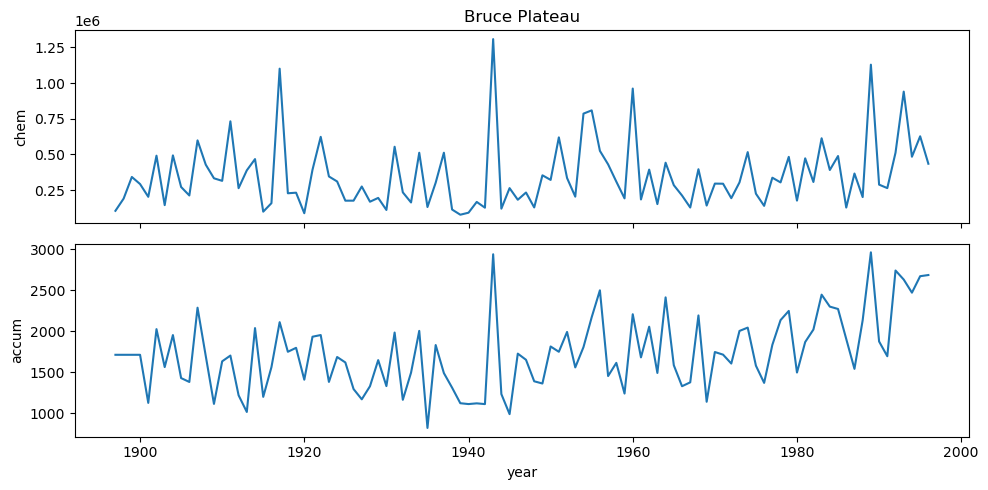

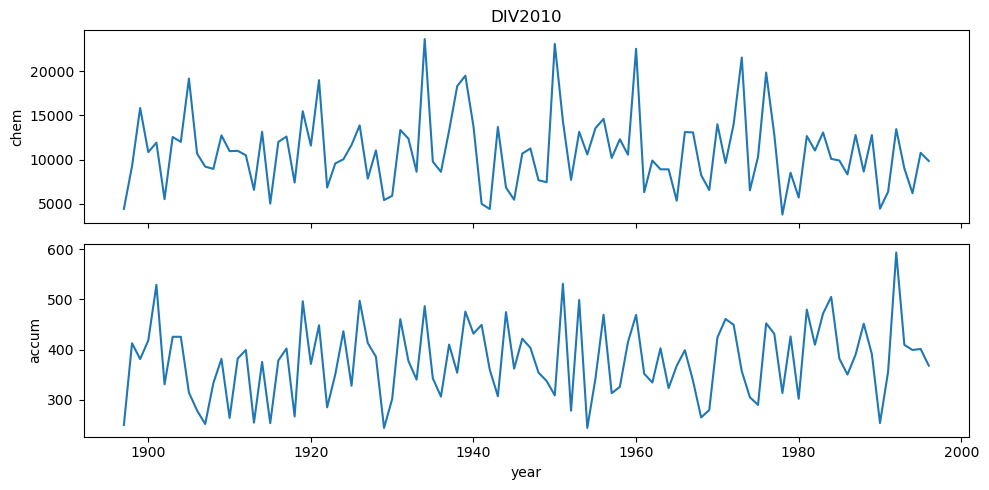

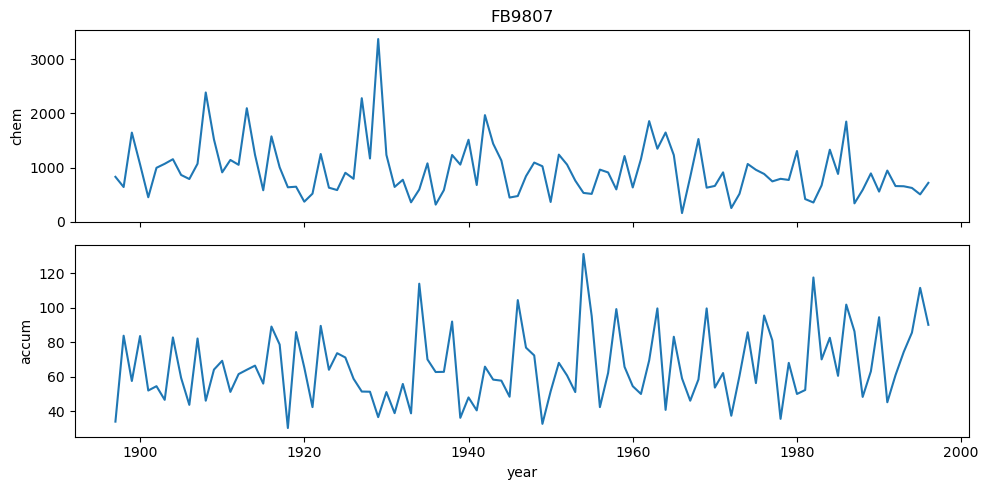

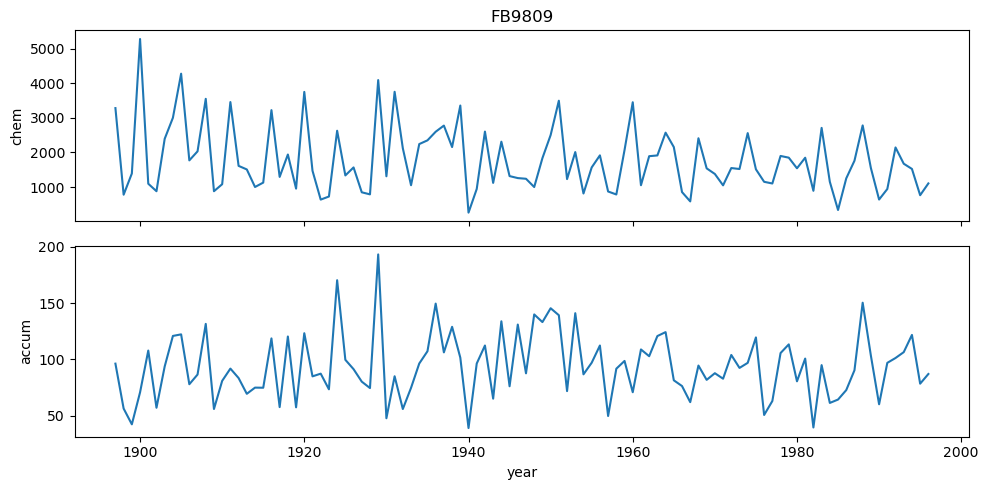

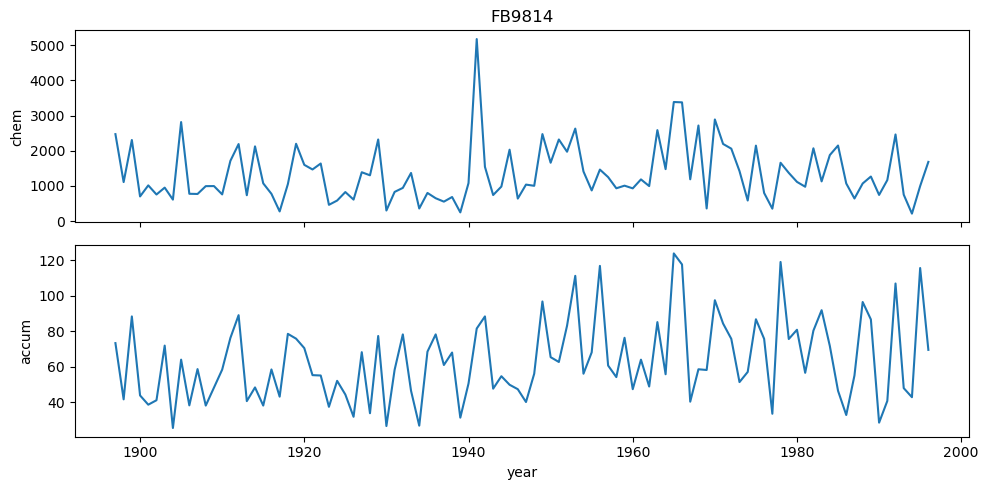

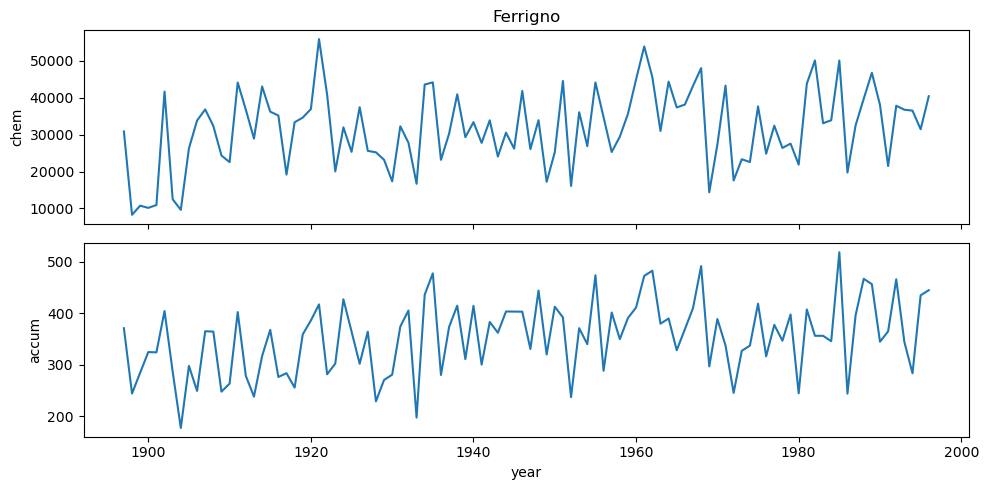

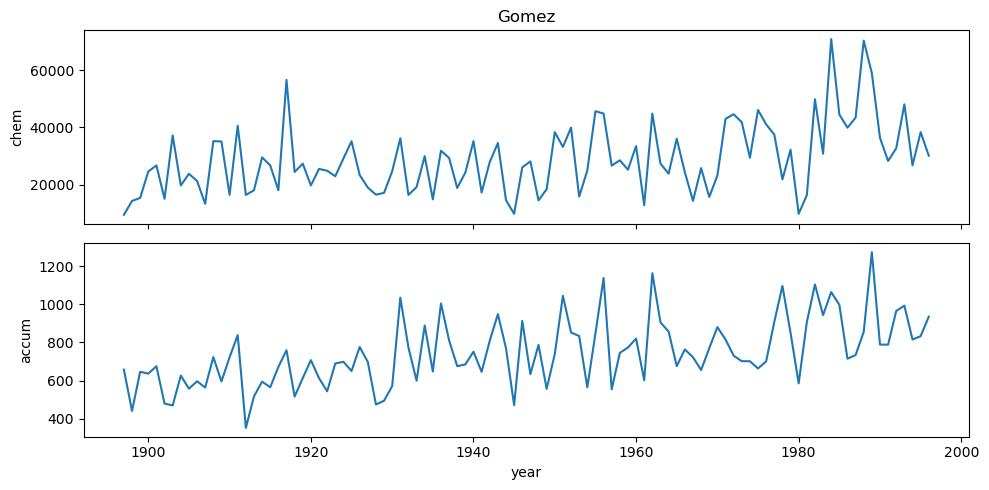

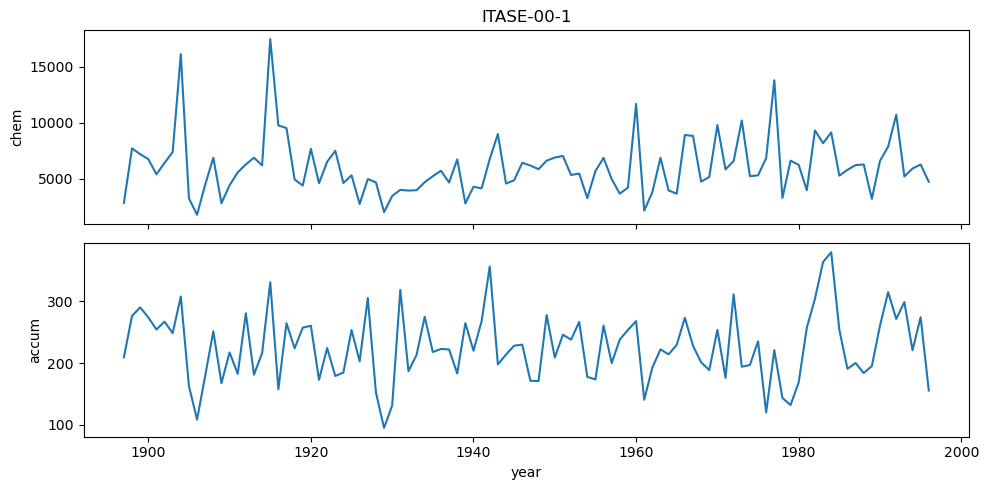

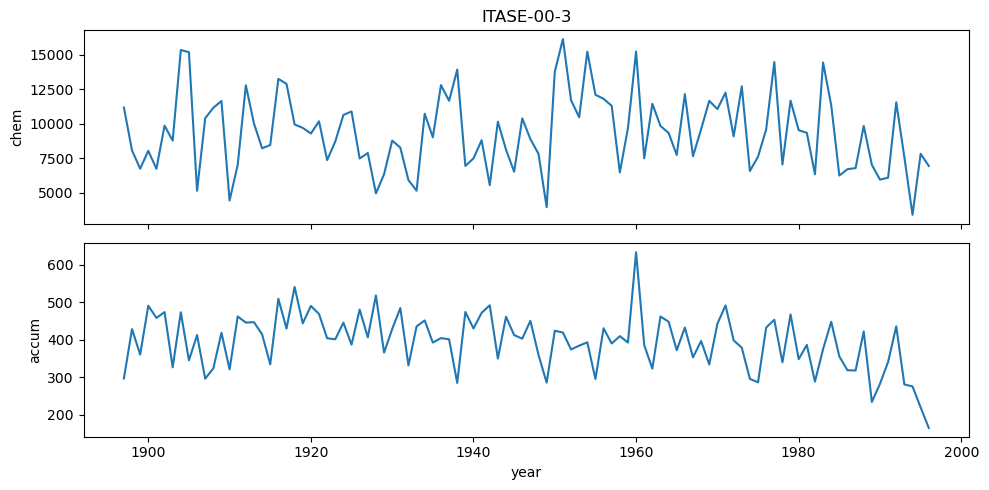

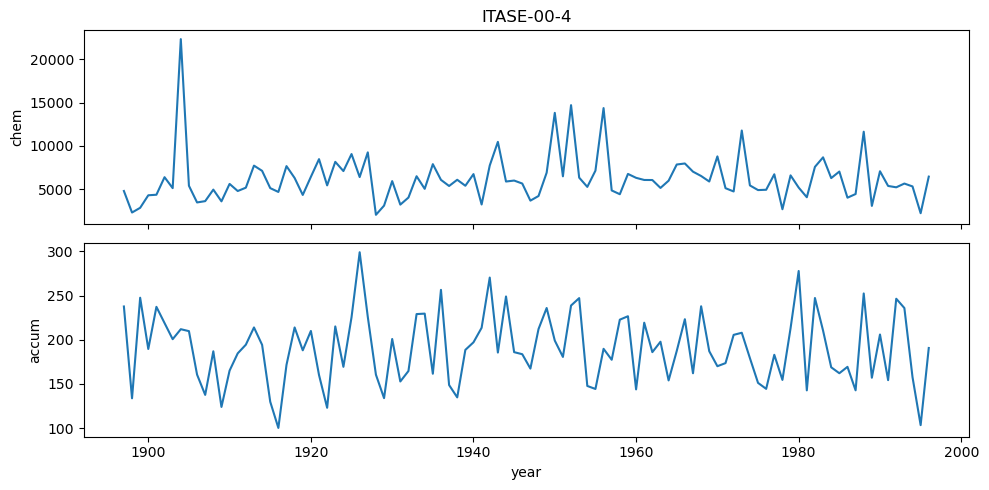

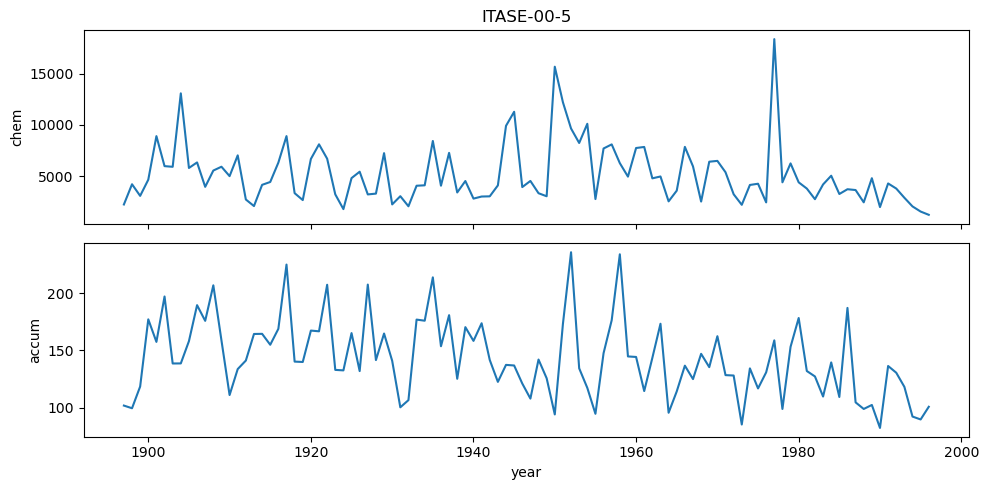

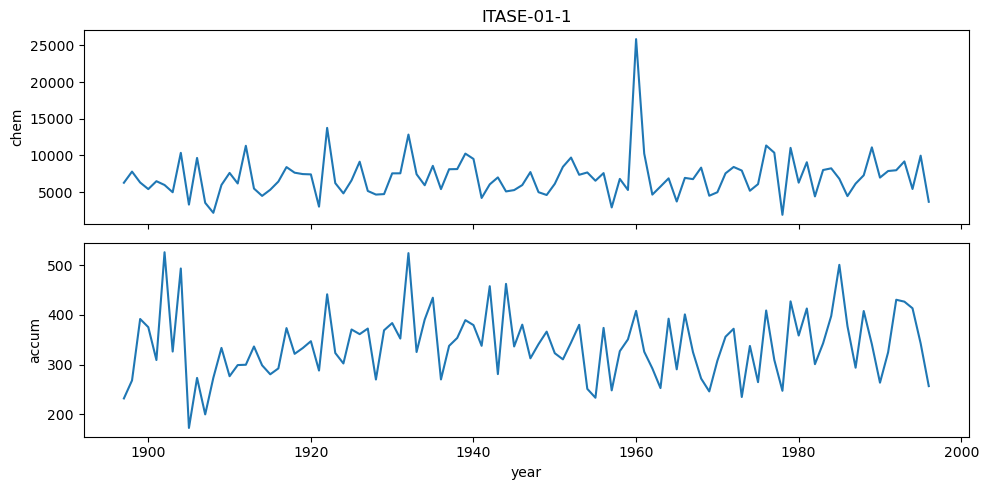

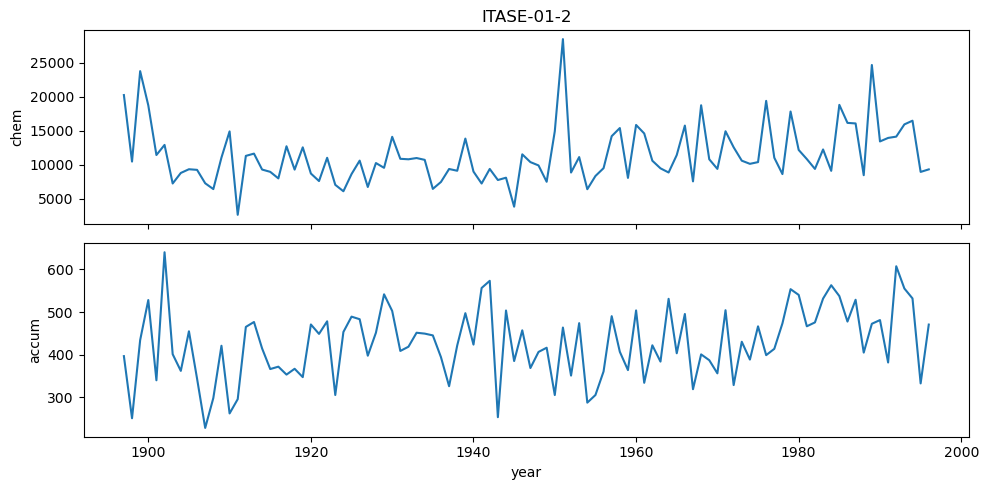

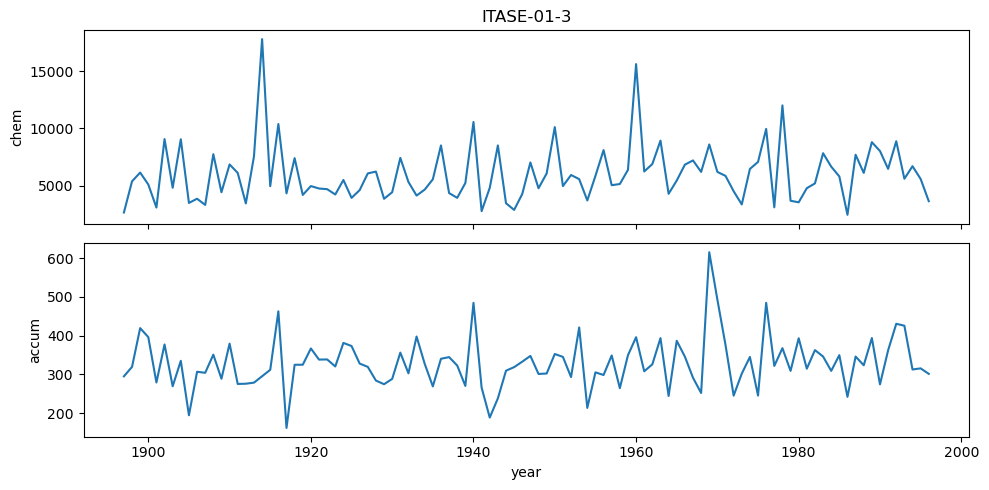

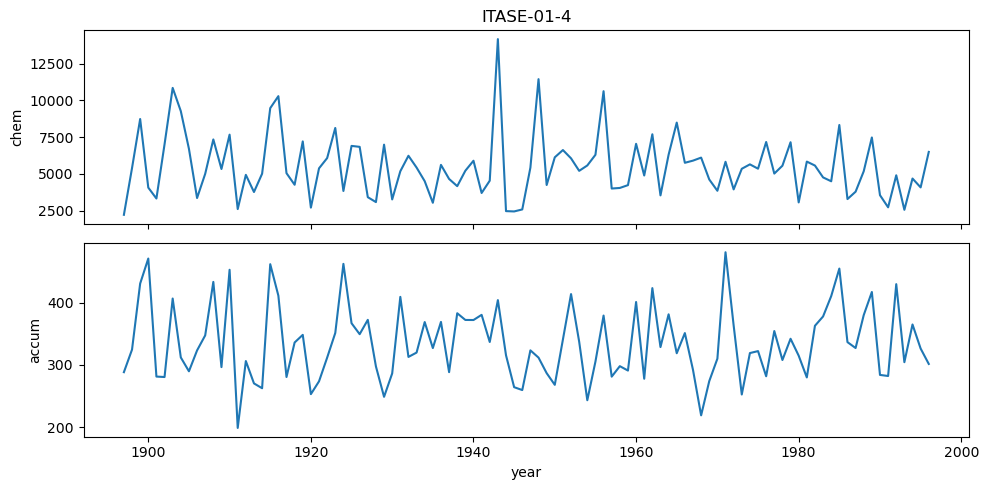

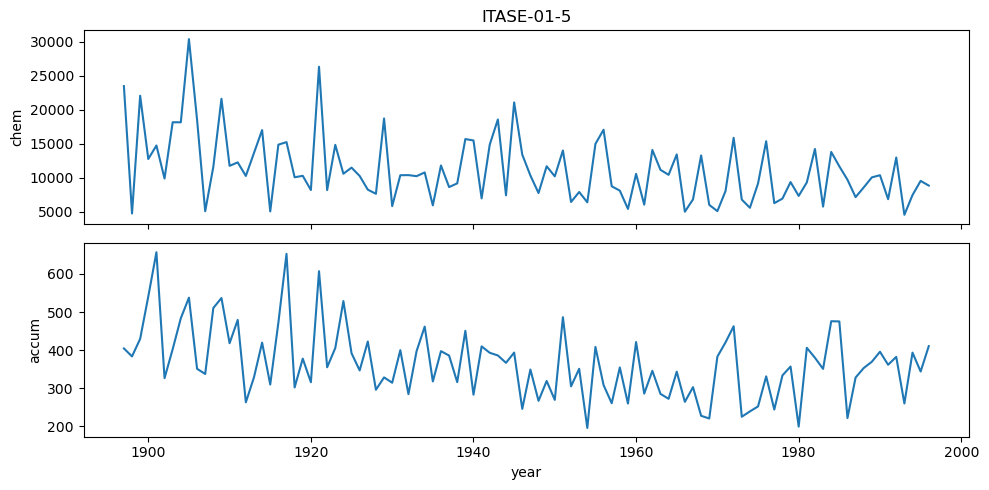

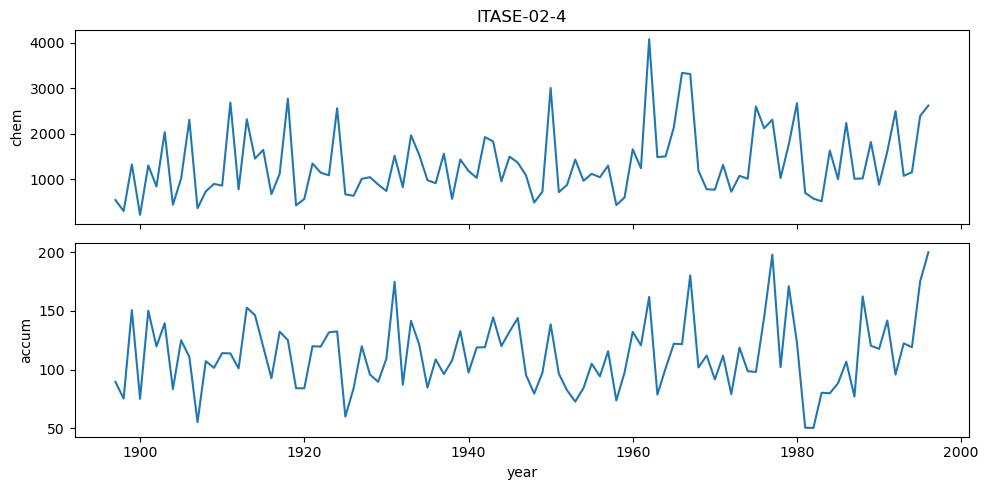

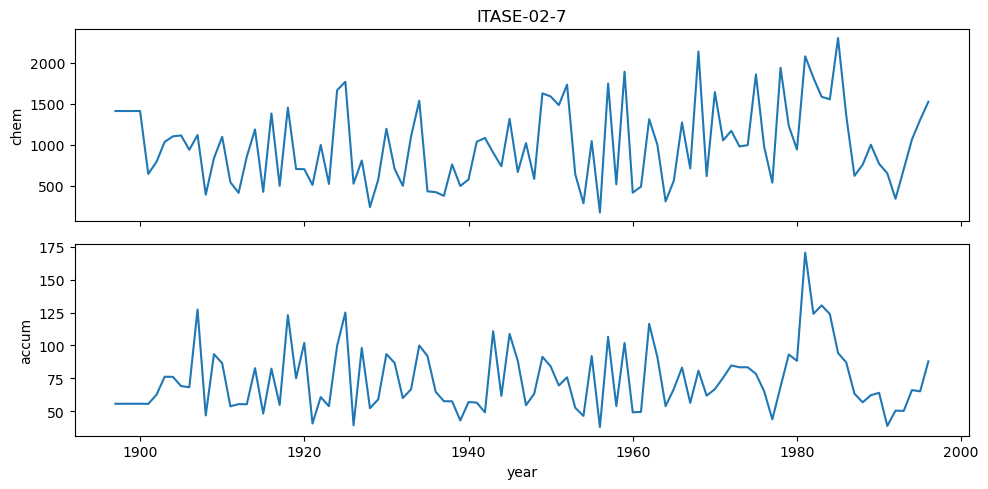

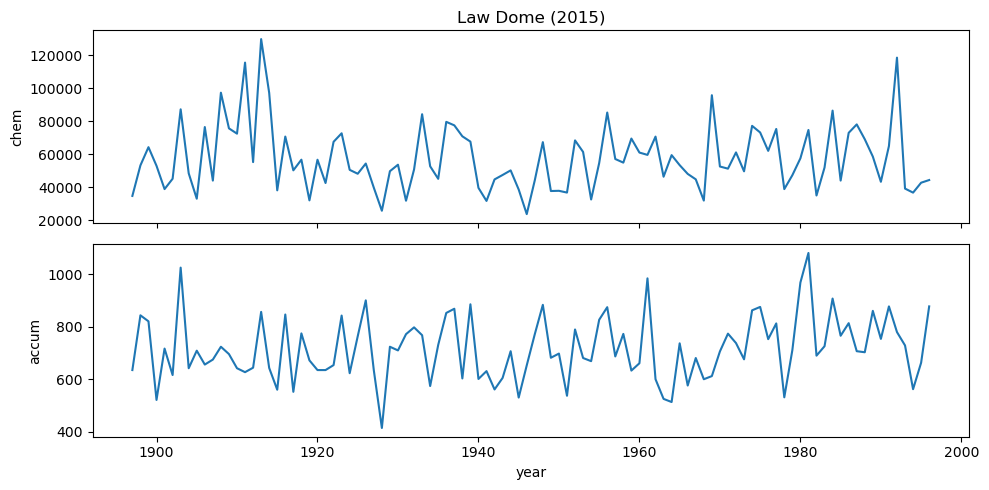

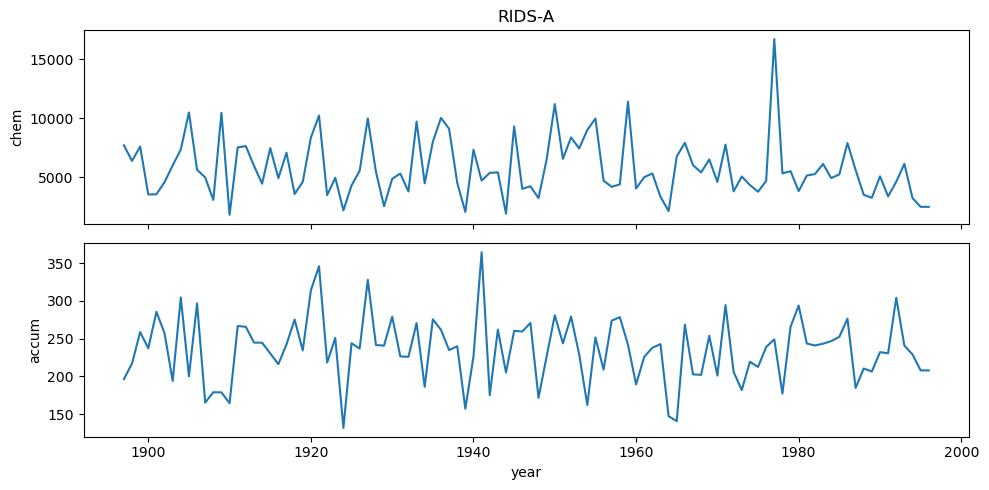

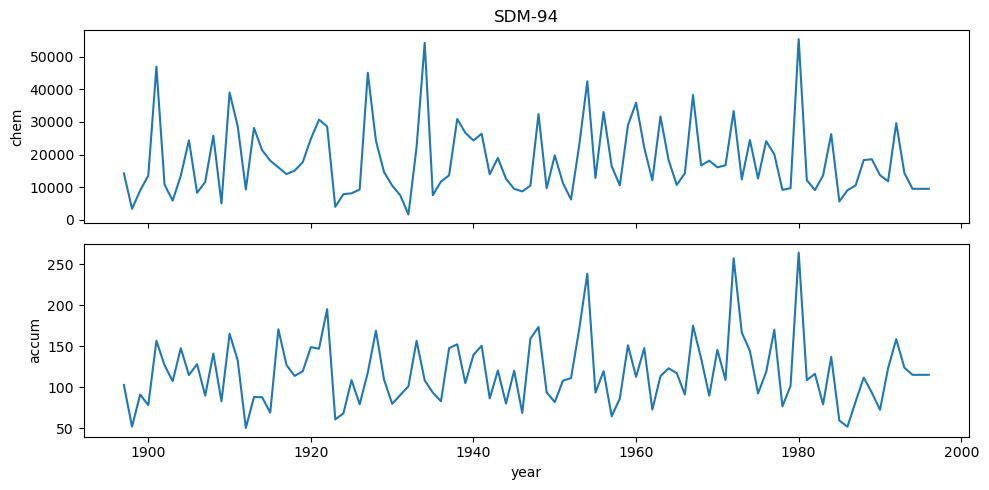

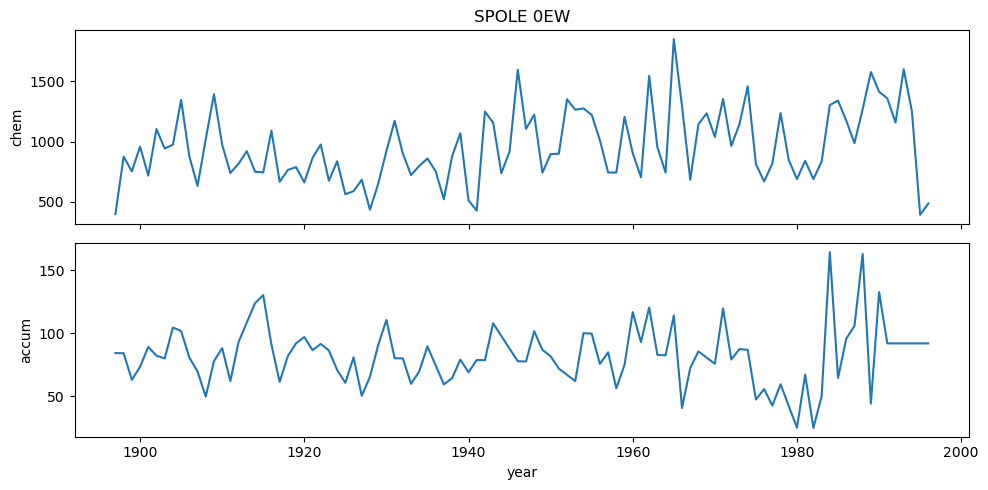

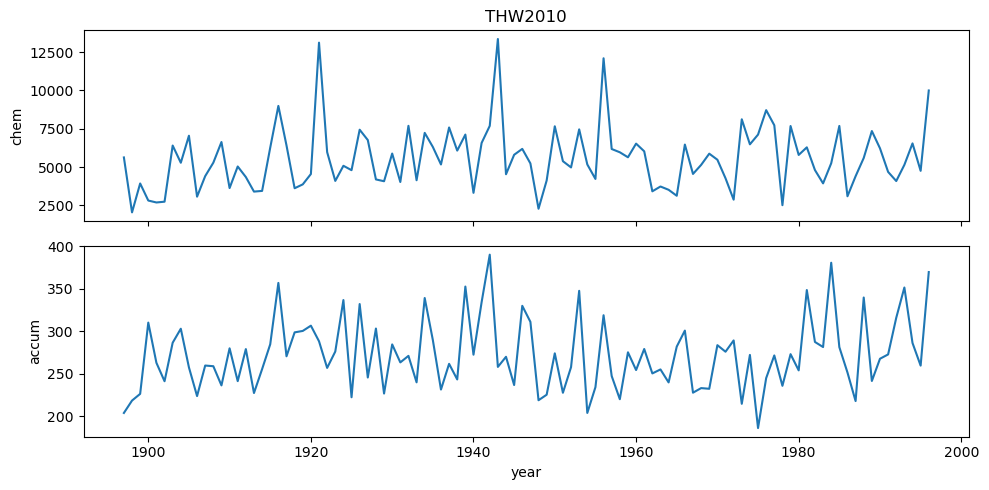

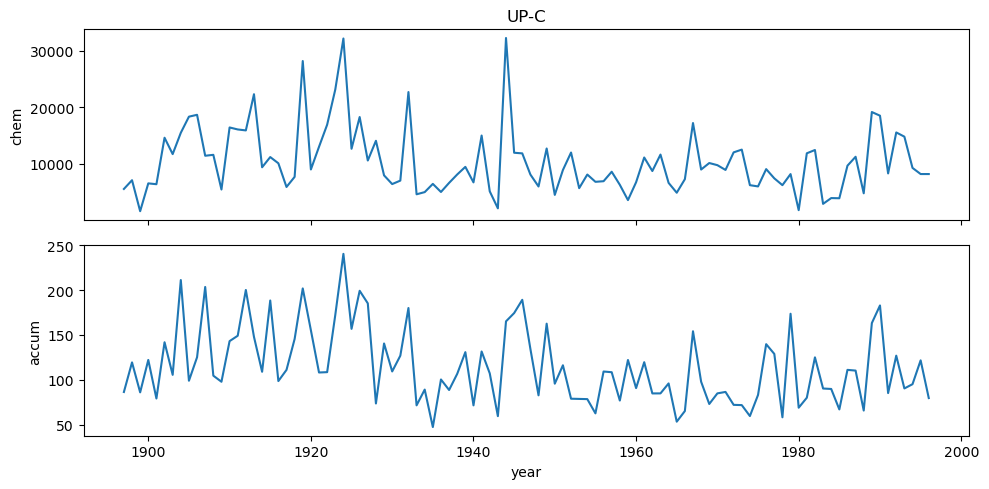

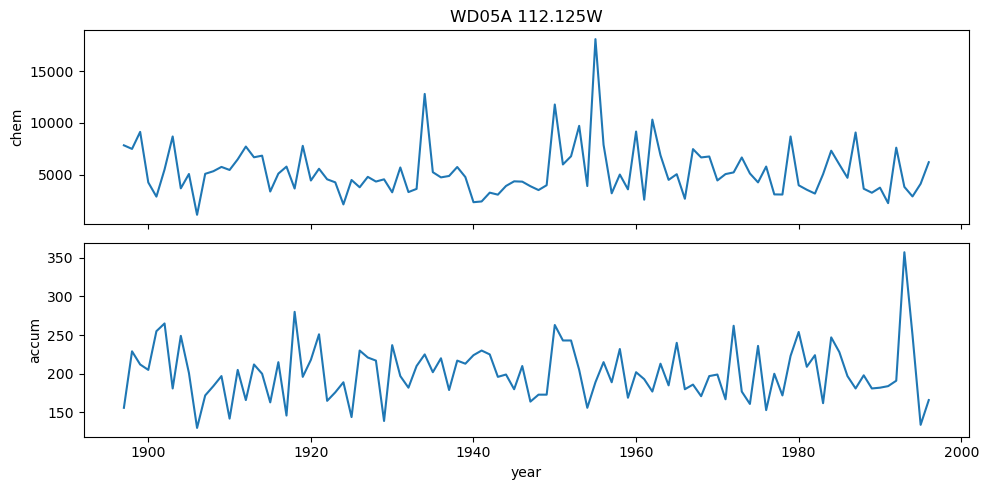

In [12]:
import pandas as pd
import matplotlib.pyplot as plt

root = "/Users/liulei/Desktop/SEMPO_copy0707/dataset/icecore"
chem = pd.read_csv(f"{root}/chem/chem.csv", index_col="year")
accum = pd.read_csv(f"{root}/accum/accum_100y.csv", index_col="year")

for site in chem.columns.intersection(accum.columns):
    fig, axes = plt.subplots(2, 1, figsize=(10, 5), sharex=True)
    axes[0].plot(chem.index, chem[site])
    axes[0].set(title=site, ylabel="chem")
    axes[1].plot(accum.index, accum[site])
    axes[1].set(xlabel="year", ylabel="accum")
    plt.tight_layout()
    plt.show()

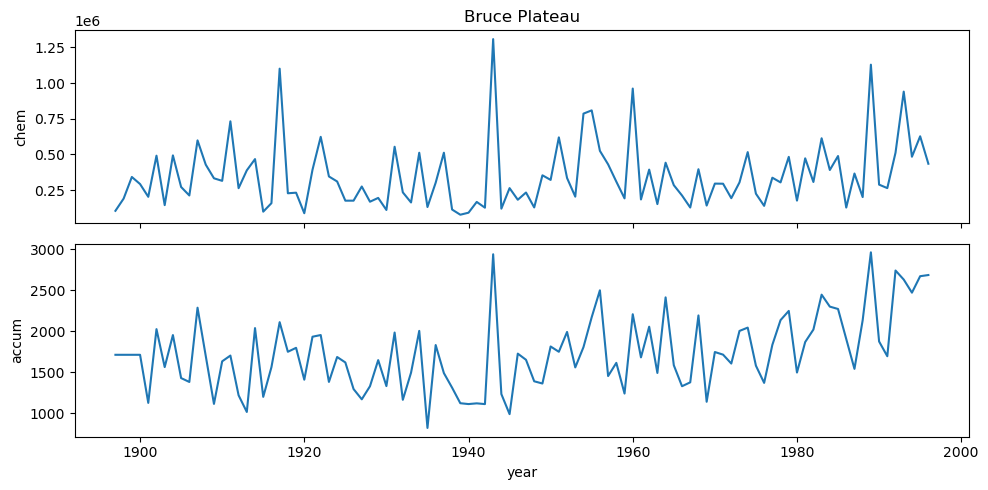

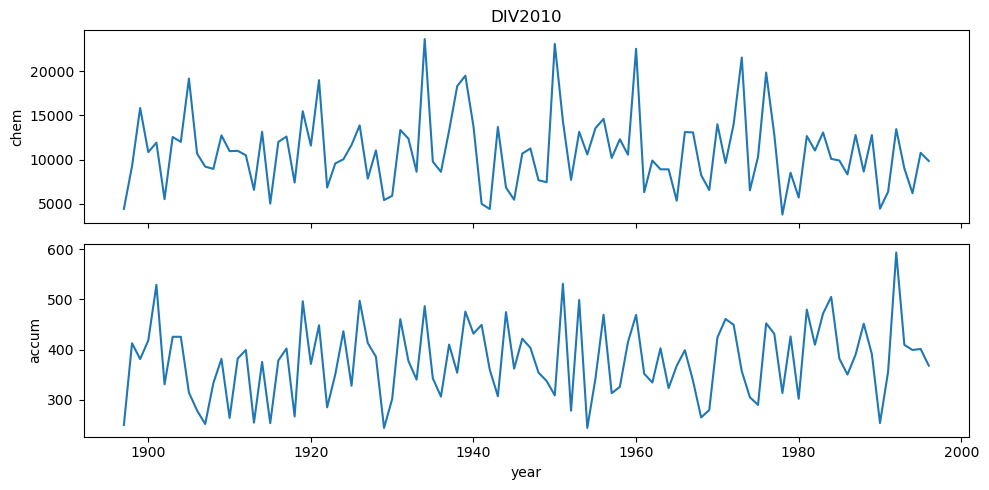

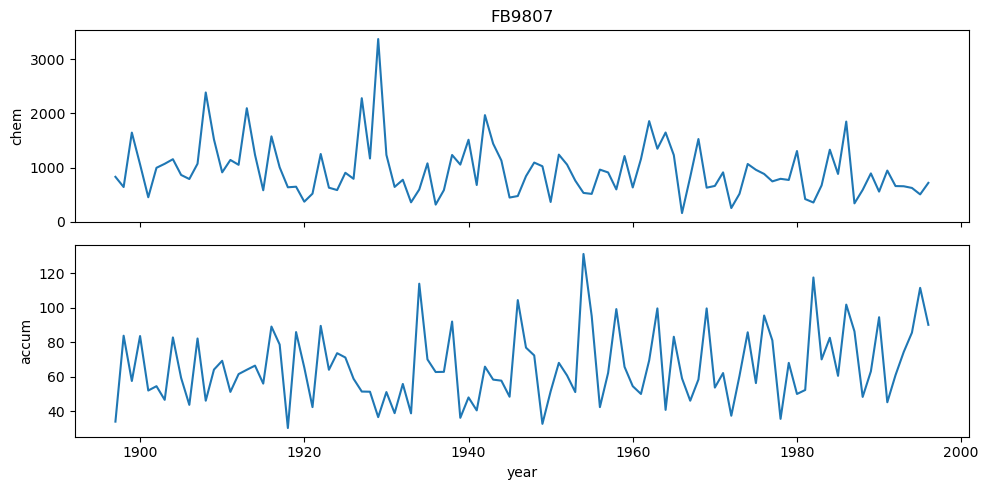

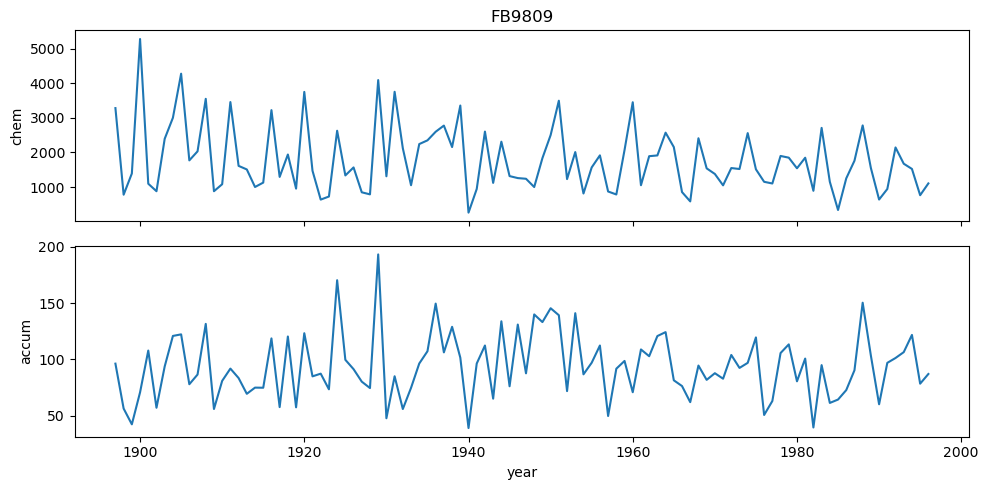

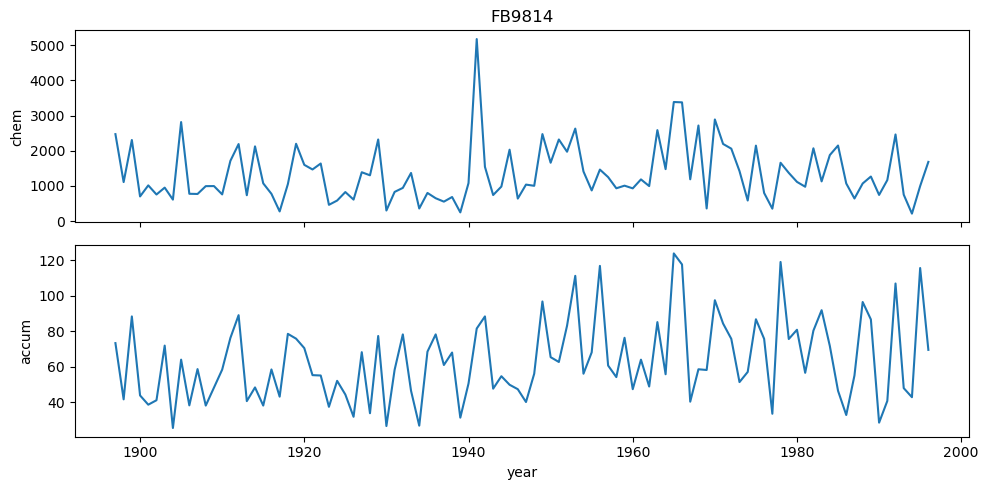

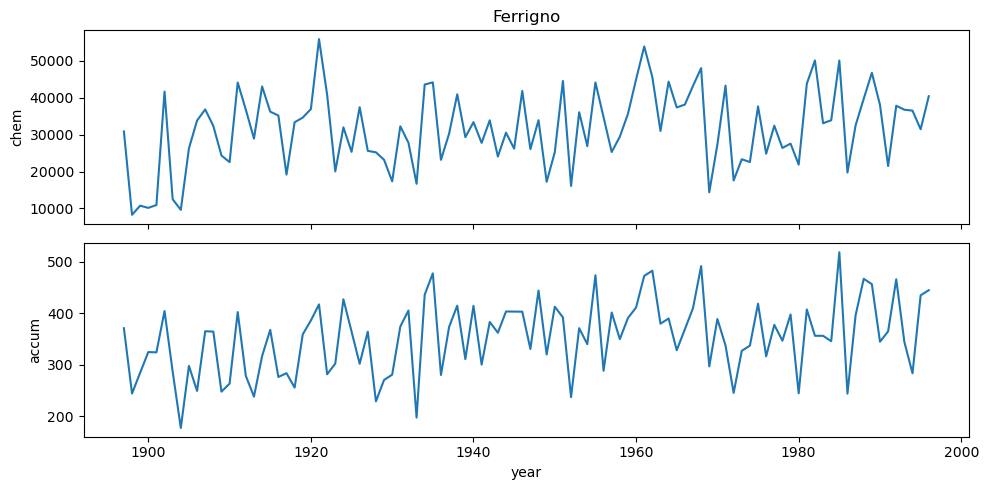

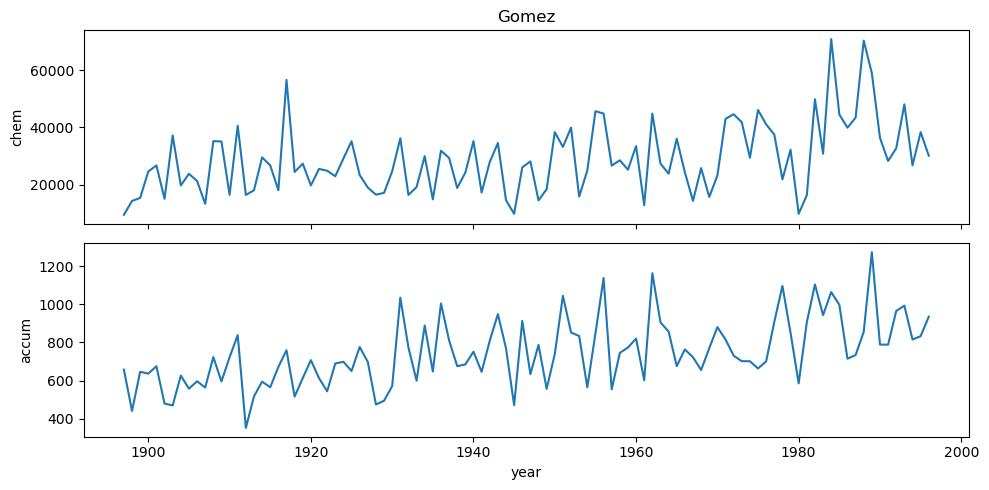

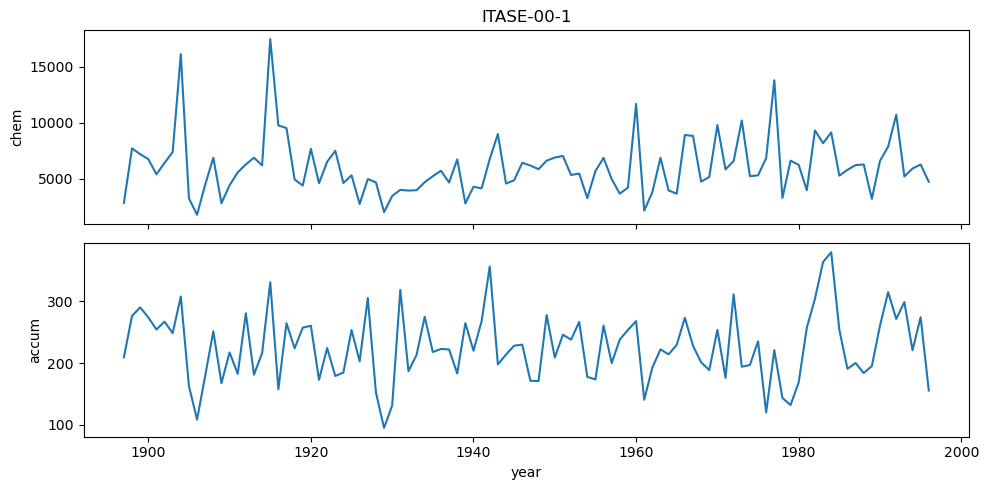

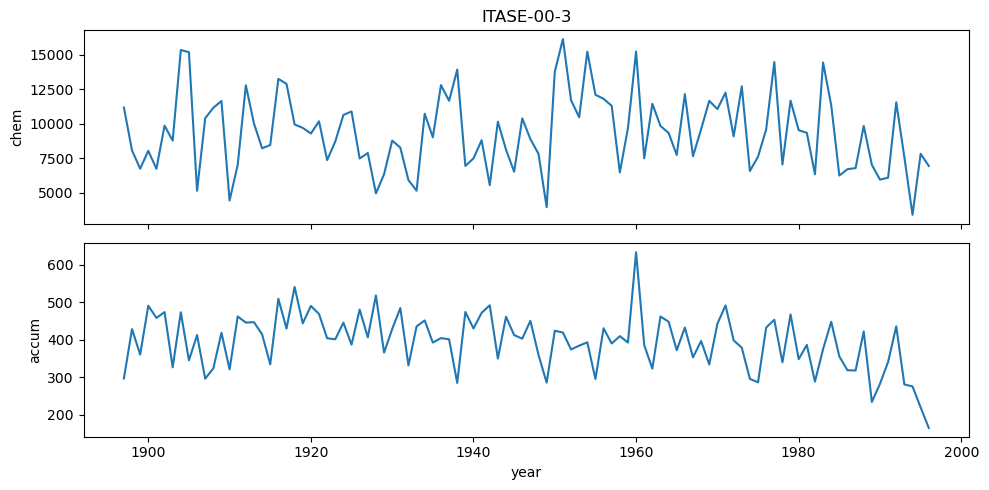

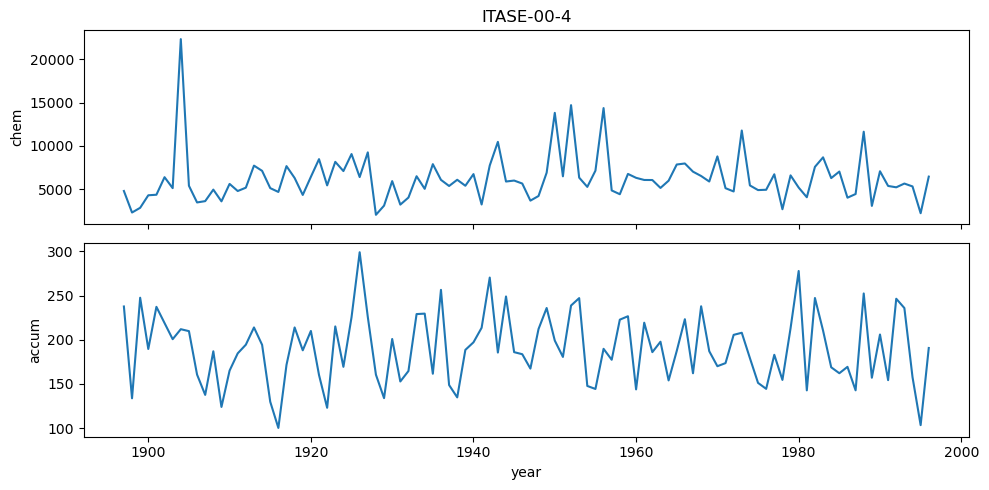

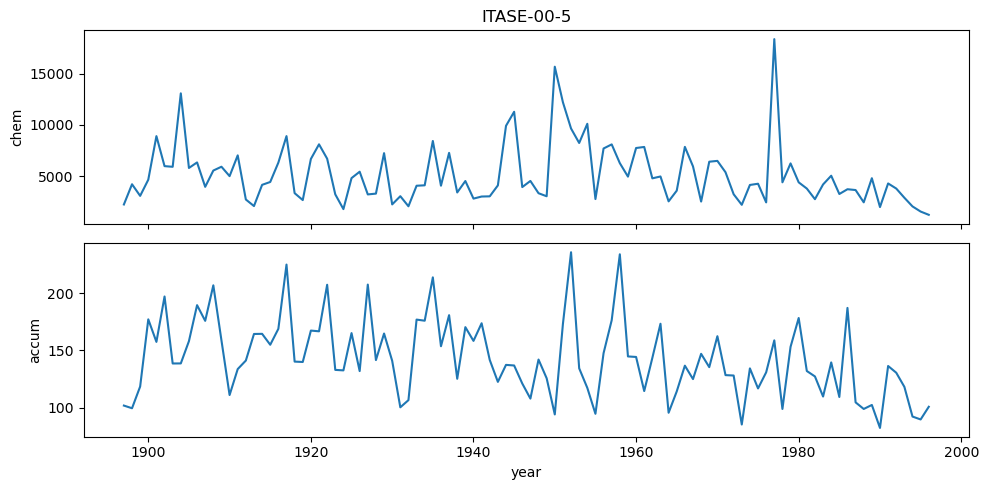

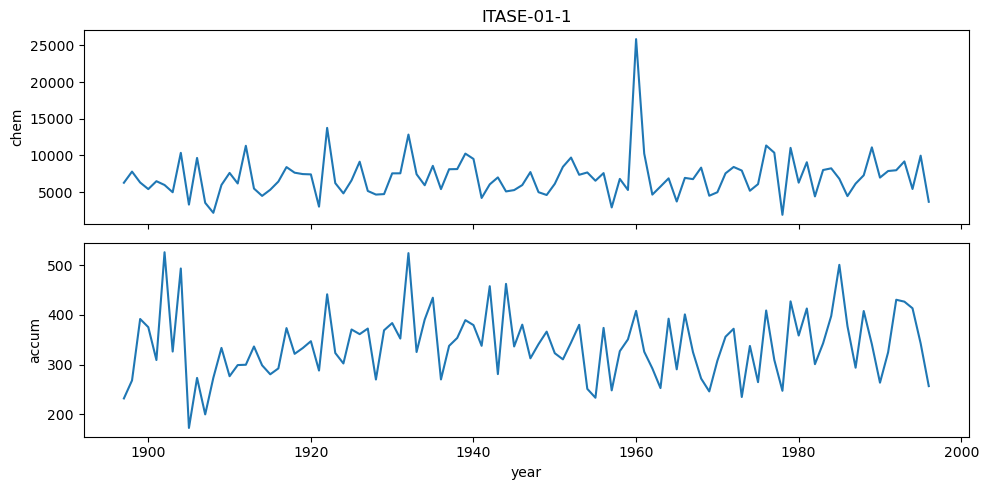

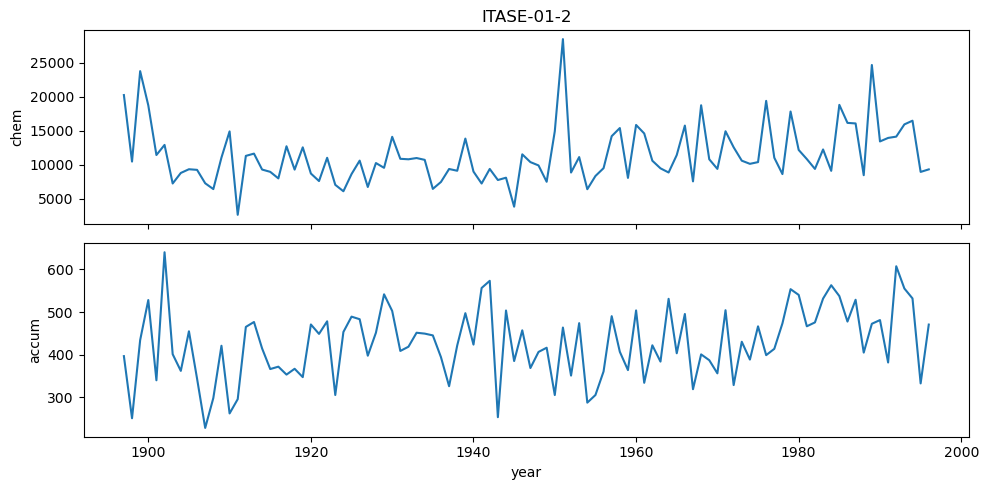

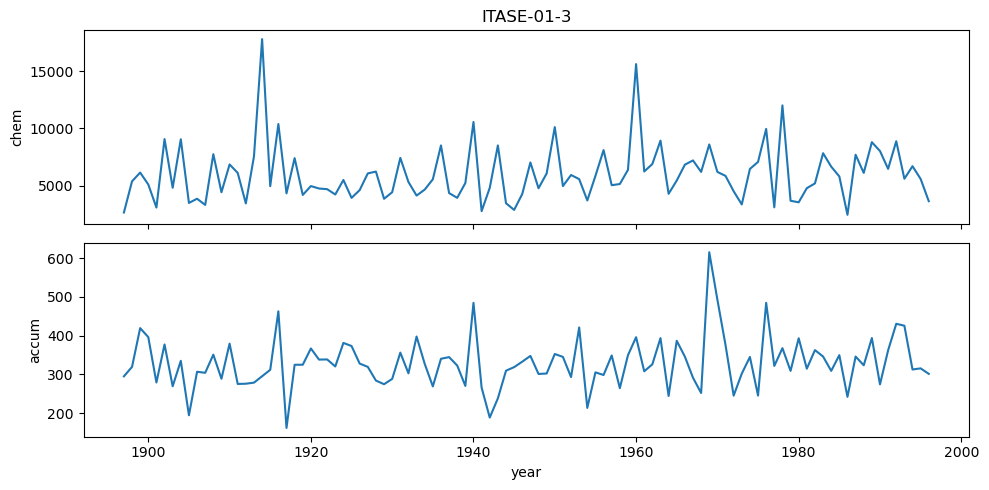

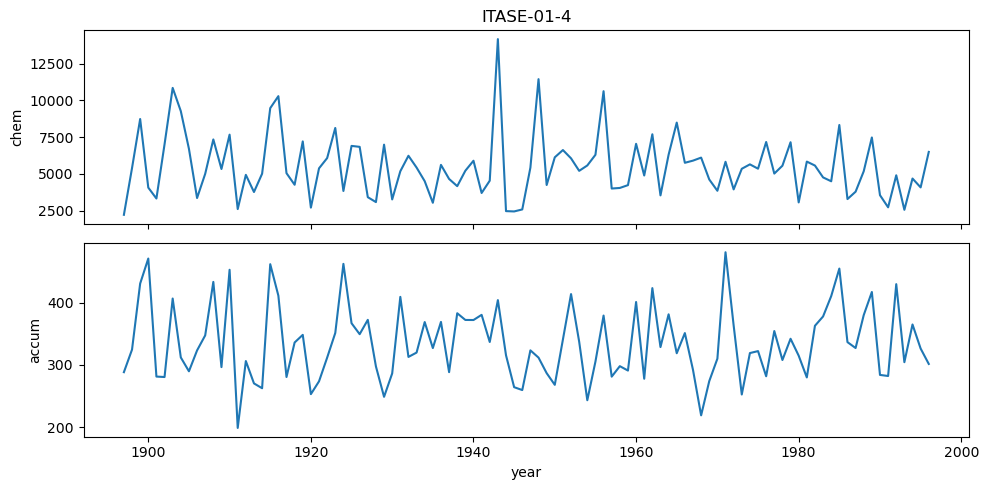

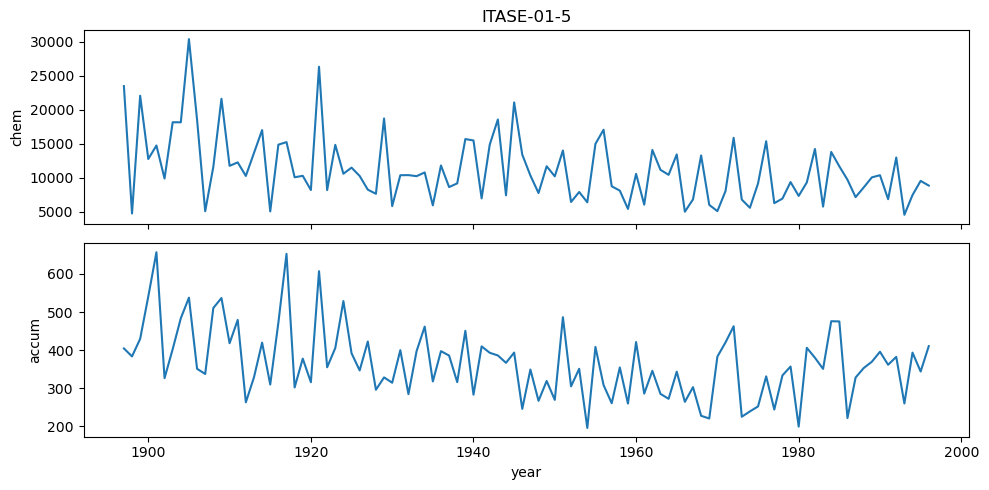

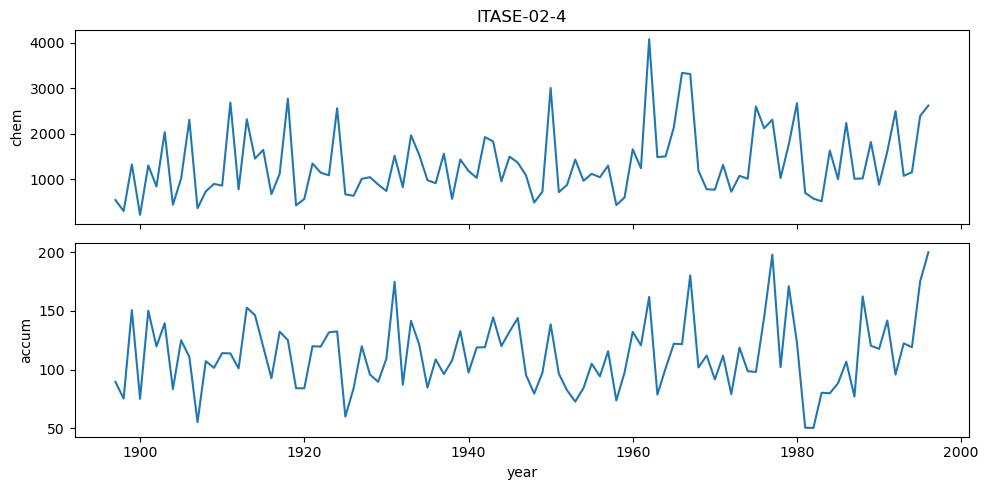

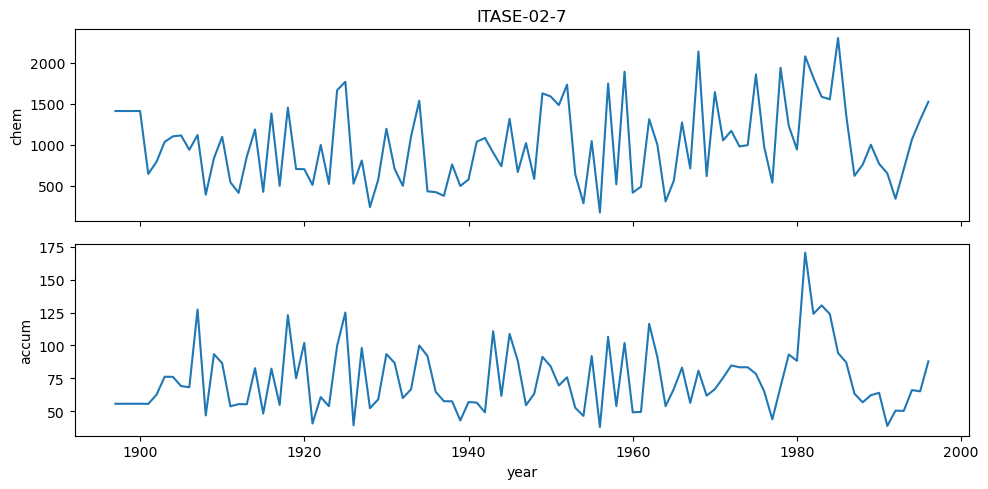

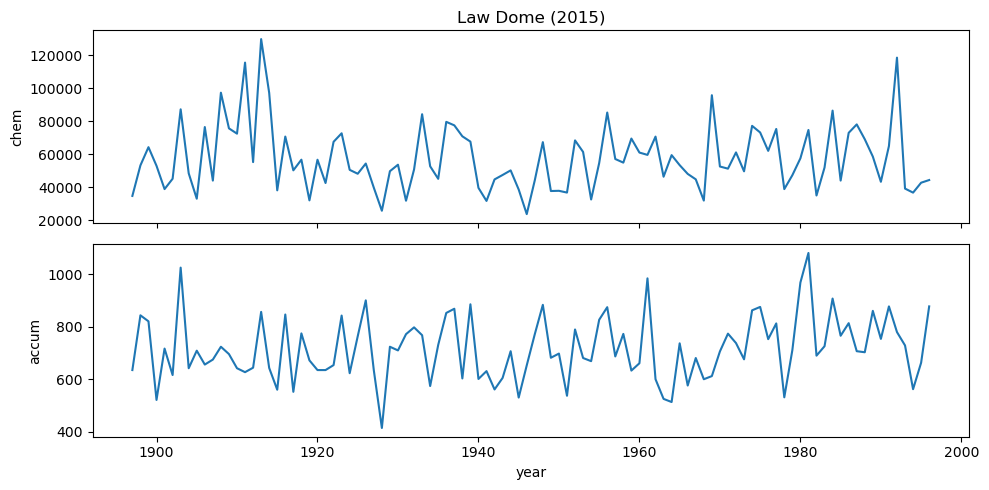

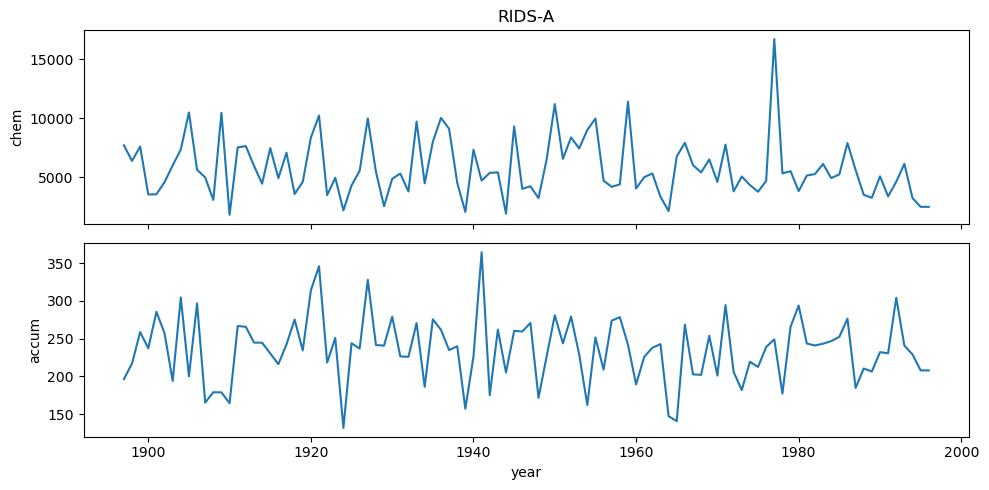

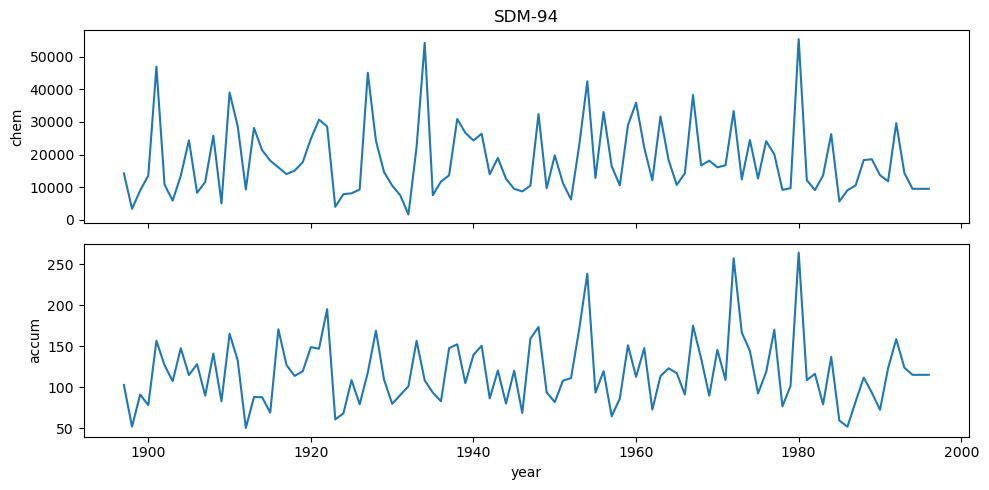

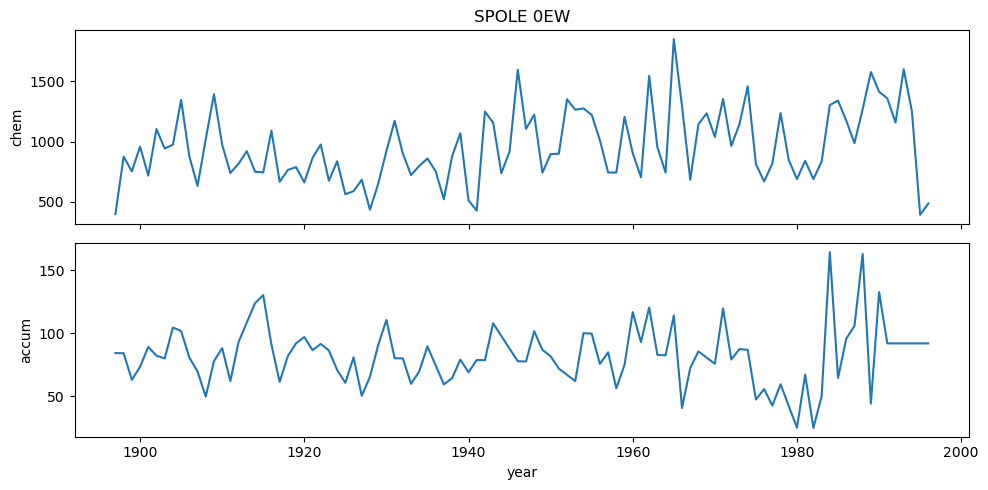

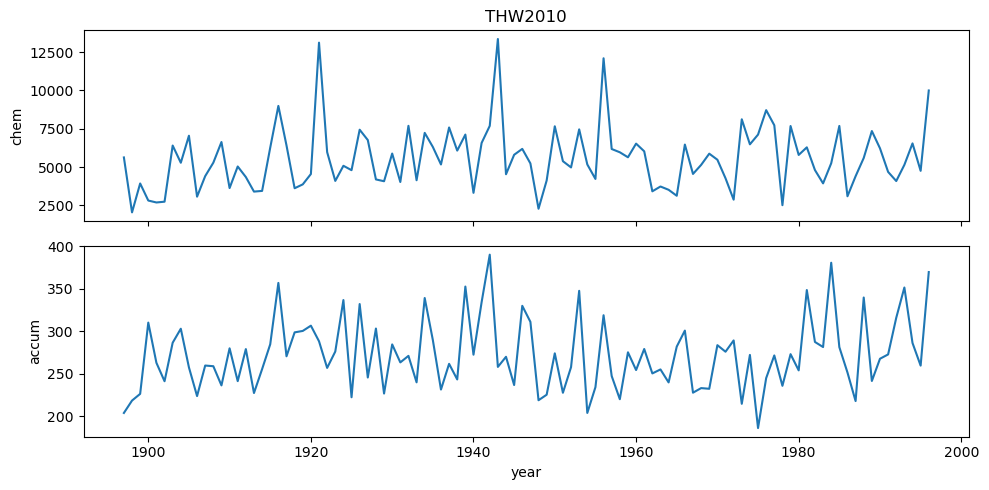

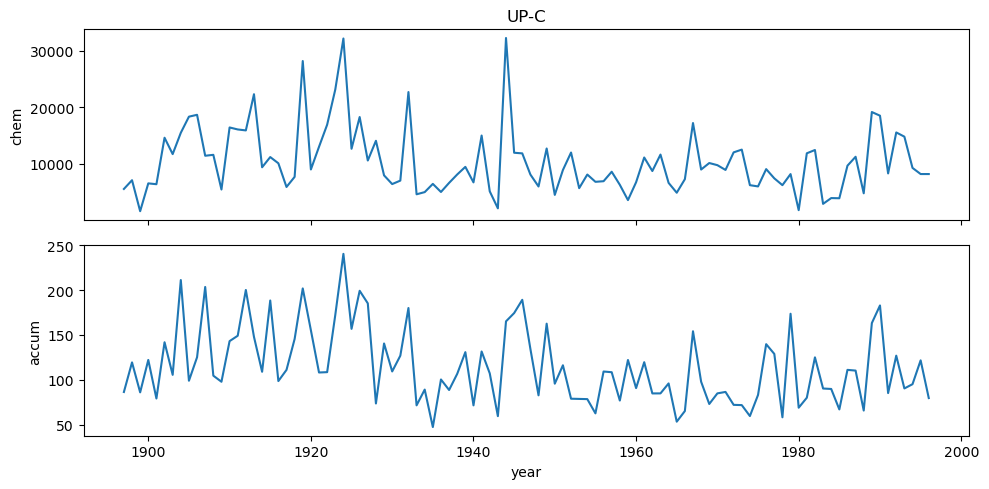

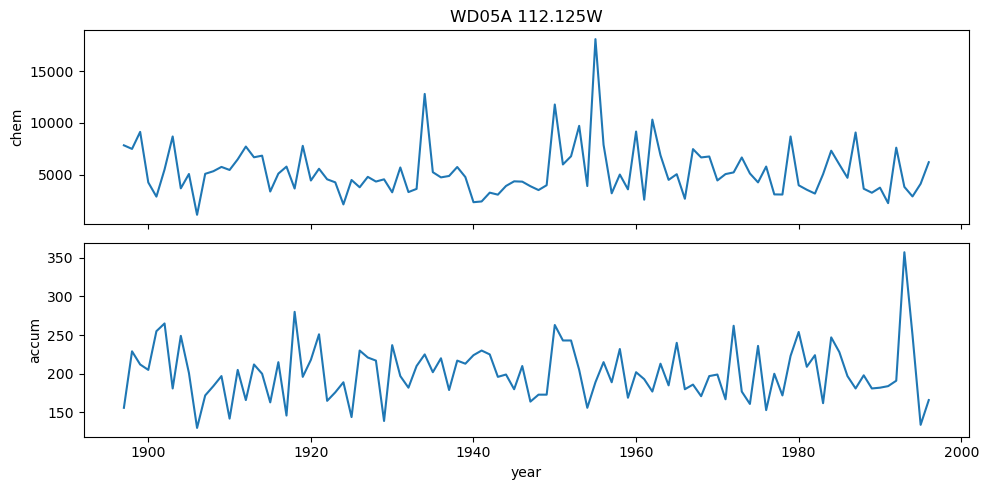

In [13]:
import pandas as pd
import matplotlib.pyplot as plt

root = "/Users/liulei/Desktop/SEMPO_copy0707/dataset/icecore"
chem = pd.read_csv(f"{root}/chem/chem.csv", index_col="year")
accum = pd.read_csv(f"{root}/accum/accum_100y.csv", index_col="year")

for site in chem.columns.intersection(accum.columns):
    fig, axes = plt.subplots(2, 1, figsize=(10, 5), sharex=True)
    axes[0].plot(chem.index, chem[site])
    axes[0].set(title=site, ylabel="chem")
    axes[1].plot(accum.index, accum[site])
    axes[1].set(xlabel="year", ylabel="accum")
    plt.tight_layout()
    plt.show()